# QDAC-II square waves


In [1]:
from time import sleep
from IPython.display import Image, display
from qcodes_contrib_drivers.drivers.QDevil import QDAC2
qdac_addr = '192.168.8.17'
qdac = QDAC2.QDac2('QDAC', visalib='@py', address=f'TCPIP::{qdac_addr}::5025::SOCKET')
from qcodes.instrument_drivers.rigol import RigolDS1074Z
rigol_addr = '192.168.8.199'
scope = RigolDS1074Z('rigol', visalib='@py', address=f'TCPIP::{rigol_addr}::INSTR')

Connected to: QDevil QDAC-II (serial:3, firmware:10-1.4) in 0.21s
Connected to: RIGOL TECHNOLOGIES DS1104Z (serial:DS1ZA171812151, firmware:00.04.03) in 0.01s


In [2]:
scope.write('*rst')
qdac.reset()

In [3]:
def capture():
    scope.write('stop')
    scope.write(":disp:data?")
    bmpdata = scope.visa_handle.read_raw()[2+9:]
    image = Image(data=bmpdata)
    display(image)

In [4]:
# Connect scope ch 3 to qdac ch 3
scope.write('chan1:disp off')
scope.write('chan3:disp on')
scope.write('chan3:bwl on')
scope.write('chan3:prob 1')
scope.write('chan3:scal 0.05')
scope.write('chan3:offs 0.0')
scope.write('trig:edge:sour chan3')
scope.write('trig:edge:level 0.05')
scope.write('tim:scal 1e-3')
scope.write('tim:offs 0')

In [5]:
square = qdac.ch03.square_wave()

In [6]:
scope.write('run')
square.start()

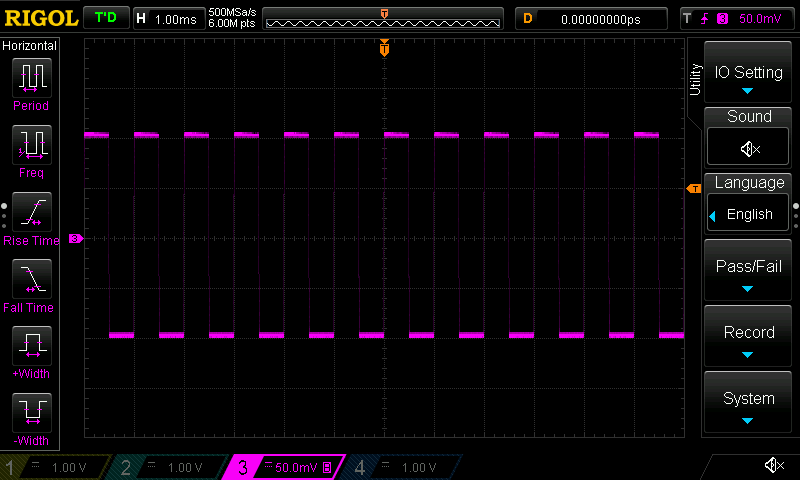

In [7]:
capture()

In [7]:
scope.write('chan1:disp off')
scope.write('chan3:disp on')
scope.write('chan3:bwl on')
scope.write('chan3:prob 1')
scope.write('chan3:scal 0.5')
scope.write('chan3:offs 0.0')
scope.write('trig:edge:sour chan3')
scope.write('trig:edge:level 0.2')
scope.write('tim:scal 100e-6')
scope.write('tim:offs 0')

In [8]:
square = qdac.ch03.square_wave(
    period_s=200e-6,
    span_V=1,
    offset_V=0,
    duty_cycle_percent=75
)
qdac.errors()

'0, "No error"'

In [9]:
scope.write('run')
square.start()

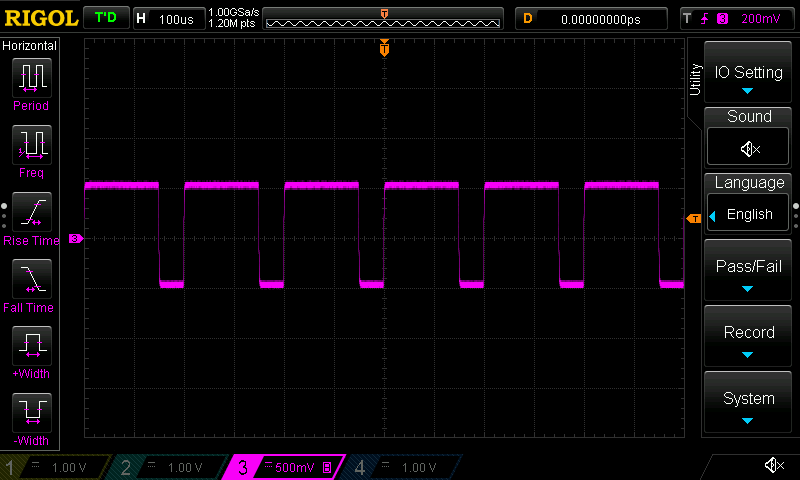

In [11]:
capture()

In [10]:
square = qdac.ch03.square_wave(
    period_s=200e-6,
    span_V=1,
    duty_cycle_percent=50,
    repetitions=4,
    slew_V_s=50000
)
qdac.errors()

'0, "No error"'

In [11]:
scope.write('tim:offs 400e-6')
scope.write('sing')
sleep(3)
square.start()

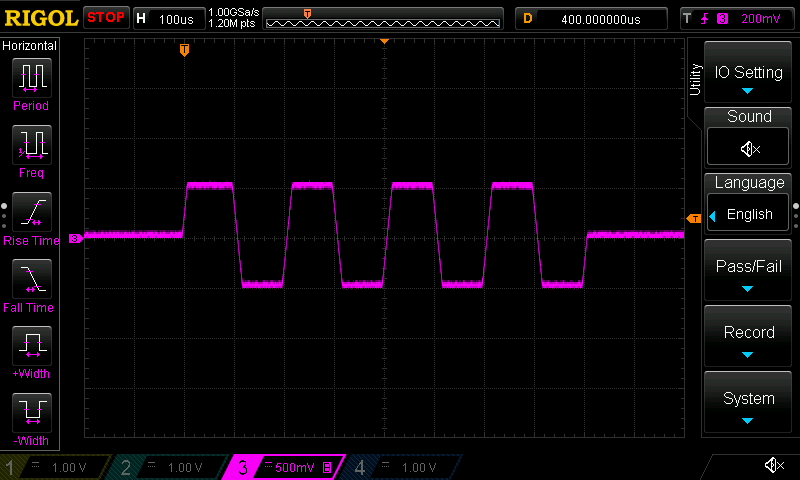

In [14]:
sleep(1)
capture()

In [12]:
scope.write('run')
sleep(2)
qdac.abort()

In [13]:
square.abort()